In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


In [2]:
dept = np.arange(5000,5500, 0.5) #Shape de 1000

sand = np.zeros(50).astype(int)
shale = np.ones(50).astype(int)

litho = np.concatenate((shale, shale, shale, shale, sand, shale, sand, sand, sand, sand, shale, sand,sand, sand,sand, sand, sand, sand,sand, sand))

porosity = np.zeros(1000)

for i, element in enumerate(litho):
    if element==1:
        porosity[i] = np.random.uniform(0.05,0.3)
    else:
        porosity[i] = np.random.uniform(0,0.05)

# Velocity Models

## Wyllie 1956

$\frac{1}{V}=\frac{\phi}{v_f} + \frac{1 - \phi}{v_m}$


## Raymer-Hunt-Gardner relations

$V = (1- \phi)^2V_0 + \phi V_{fl}$

$V_0 = 5.4 m/s$ (Velocidad de los minerales. Tabla 7.3.1 The Rock Physics Handbook : Tools for Seismic Analysis of Porous Media)

$V_{fl} = 1 m/s$ (Velocidad del agua)

In [3]:
Vm_ft_s = 19000
Vf_ft_s = 4800

Vm_km_s = Vm_ft_s * 0.0003048
Vf_km_s = Vf_ft_s * 0.0003048

In [4]:
v_raymer = (np.power(1 - porosity, 2) * Vm_km_s) + (porosity * Vf_km_s) #Esta ecuacion va en km/s

v_m_s_raymer = v_raymer*1000

v_ft_us_raymer = v_m_s_raymer * (3.28084) * (1/1000000)

dtp_raymer = 1/v_ft_us_raymer

In [5]:
v_wyllie = 1/ ((porosity/4800) + ((1-porosity)/19000)) #Esta ecuacion va en ft/sec Wyllie 1956
v_ft_us_wyllie = v_wyllie *(1/1000000)
dtp_wyllie = 1/v_ft_us_wyllie

# Plot Models

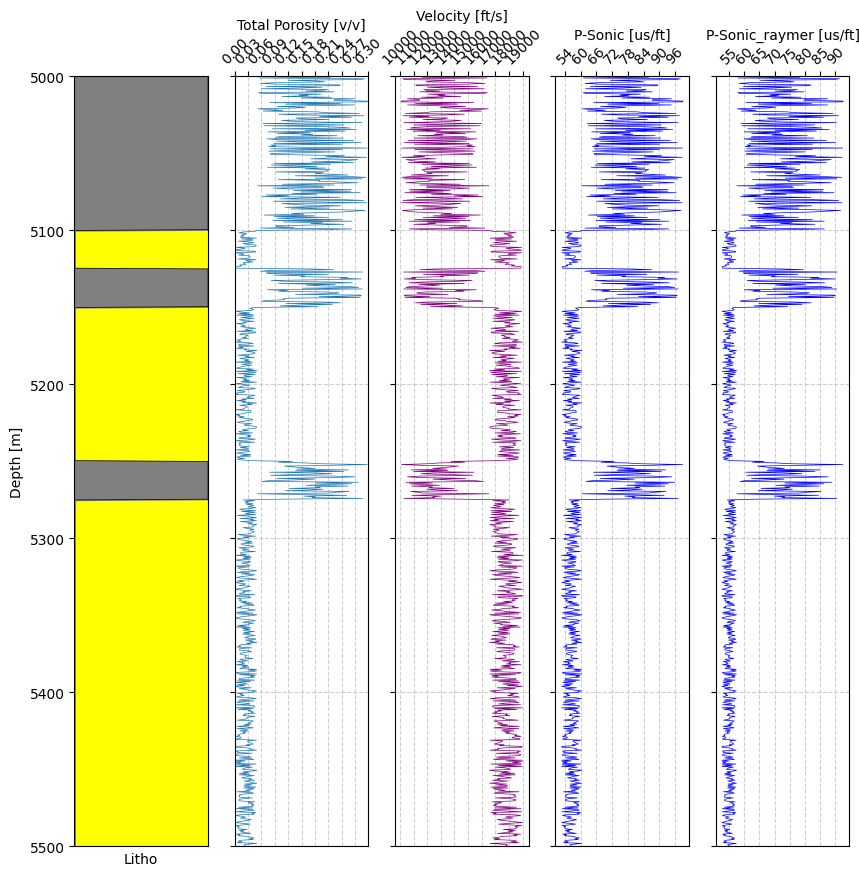

In [6]:

fig, ax = plt.subplots(1, 5, figsize=(10,10), sharey=True)

ax[0].plot(litho, dept, color='k', lw=0.5)

ax[0].set_ylabel('Depth [m]')
ax[0].set_ylim([5000, 5500])
ax[0].invert_yaxis()

ax[0].set_xlim([0, 1])
ax[0].set_xlabel('Litho')
ax[0].fill_between(litho, dept, 5500, color='yellow')
ax[0].fill_between(litho, dept, 5000, color='grey')

ax[1].plot(porosity, dept, lw=0.5)
ax[1].set_xlim([0, 0.3])
ax[1].set_xlabel('Total Porosity [v/v]')

ax[2].plot(v_wyllie, dept, color='purple', lw=0.5)
ax[2].set_xlabel('Velocity [ft/s]')

ax[3].plot(dtp_wyllie, dept, color='blue', lw=0.5)
ax[3].set_xlabel('P-Sonic [us/ft]')

ax[4].plot(dtp_raymer, dept, color='blue', lw=0.5)
ax[4].set_xlabel('P-Sonic_raymer [us/ft]')

ax[0].tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False)
for i in range(1,5):
    ax[i].xaxis.set_label_position('top') 
    ax[i].xaxis.tick_top()
    ax[i].grid(True, linestyle='--', alpha=0.6, zorder=0)
    ax[i].xaxis.set_major_locator(MaxNLocator(nbins=10))
    ax[i].tick_params(axis='x', rotation=45)

plt.show()

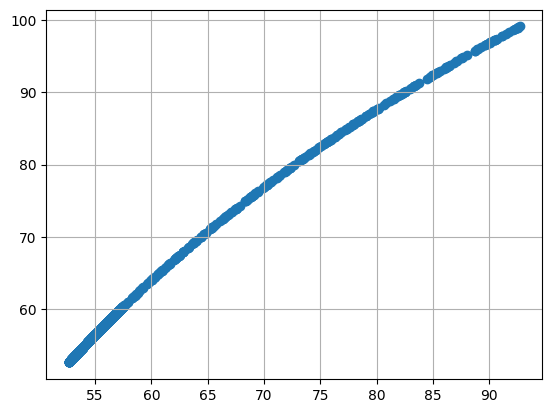

In [7]:
plt.scatter(dtp_raymer, dtp_wyllie)
plt.grid(zorder=0)
plt.show()

# Earth Model

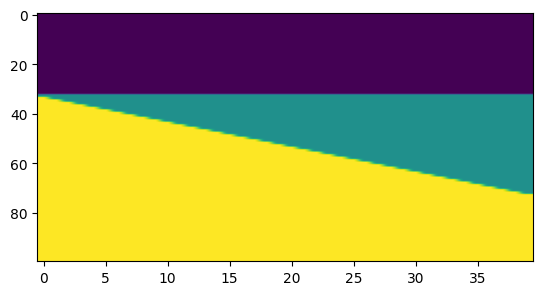

In [8]:
length, depth = 40, 100
model = 1 + np.tri(depth, length, -depth//3, dtype=int)
model[:depth//3,:] = 0
plt.imshow(model, cmap='viridis', aspect=0.2)
plt.show()

In [9]:
porosity_model = np.empty((depth, length))

In [10]:
for columna in range(len(model[0])):
    for fila in range(len(model)):
        
        if model[fila][columna]==0 or model[fila][columna]==2:
            porosity_model[fila][columna]= np.random.uniform(0.25,0.3)
        else:
            porosity_model[fila][columna] = np.random.uniform(0,0.01)
    

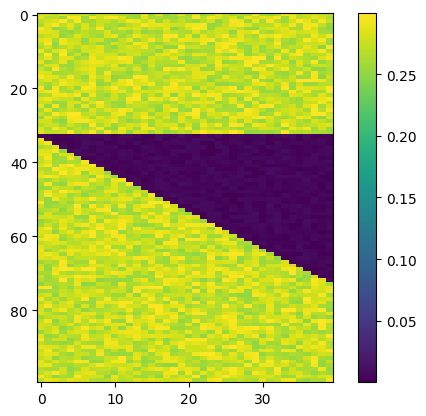

In [11]:
plt.imshow(porosity_model, aspect=0.5)
plt.colorbar()
plt.show()

In [12]:
velocity_model= 1/ ((porosity_model/4800) + ((1-porosity_model)/19000)) #Esta ecuacion va en ft/sec Wyllie 1956


In [13]:
density_model = 0.23 * np.power(velocity_model, 0.25) #Ecuacion de Gardner 1974 va en g/cc

In [14]:
imp =porosity_model * density_model

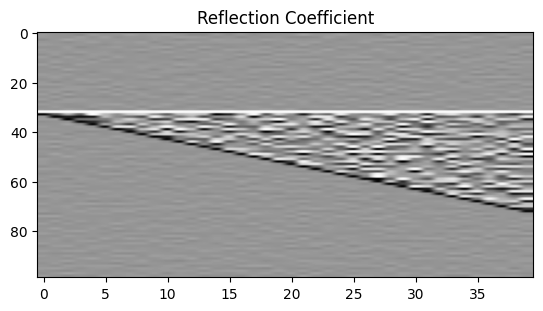

In [15]:
rc =  (imp[1:,:] - imp[:-1,:]) / (imp[1:,:] + imp[:-1,:])

plt.imshow(rc, cmap='Greys', aspect=0.2)
plt.title('Reflection Coefficient')
plt.show()

Text(0.5, 1.0, 'Source Wavelet')

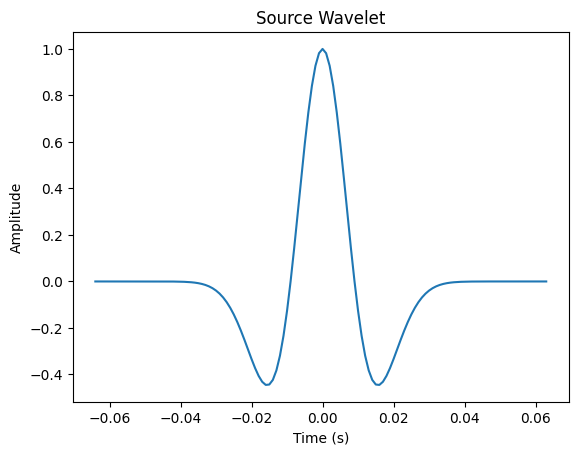

In [16]:
def ricker(f, length=0.128, dt=0.001):
    t = np.arange(-length/2, (length-dt)/2, dt)
    y = (1.0 - 2.0*(np.pi**2)*(f**2)*(t**2)) * np.exp(-(np.pi**2)*(f**2)*(t**2))
    return t, y
 
f = 25 # A low wavelength of 25 Hz
t, w = ricker(f)
plt.plot(t,w)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Source Wavelet")

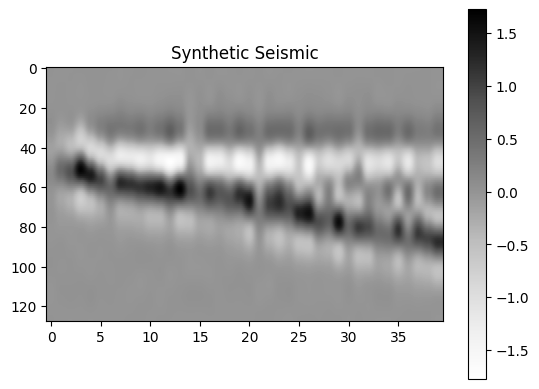

In [17]:
synth = np.apply_along_axis(lambda t: np.convolve(t, w, mode='same'),
                            axis=0,
                            arr=rc)

plt.imshow(synth, cmap="Greys", aspect=0.2)
plt.title('Synthetic Seismic')
plt.colorbar()
plt.show()

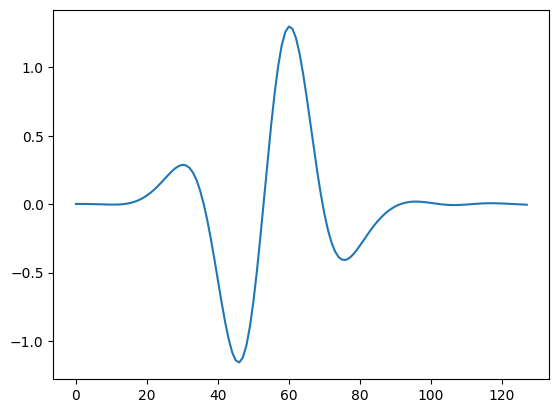

In [20]:
plt.plot(synth[:,10])